# Purpose

1. Predict interest rates based on Fico Score, amount requested, and loan length.
2. Trying to get the lowest interest rates as possible for business owners.

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score

loan_df = pd.read_csv("Data/LoanData.csv")

loan_df["fico_range"].unique()
loan_df["fico_score"] = loan_df["fico_range"].str.split("-").apply(lambda x: x[1])
loan_df['fico_score'] = pd.to_numeric(loan_df['fico_score'])

loan_df.head()

,interest_rate,fico_range,amount_requested,amount_funded_by_investors,loan_length,fico_score
0,8.90,735-739,20000.0,20000.0,36.0,739
1,12.12,715-719,19200.0,19200.0,36.0,719
2,21.98,690-694,35000.0,35000.0,60.0,694
3,9.99,695-699,10000.0,9975.0,36.0,699
4,11.71,695-699,12000.0,12000.0,36.0,699


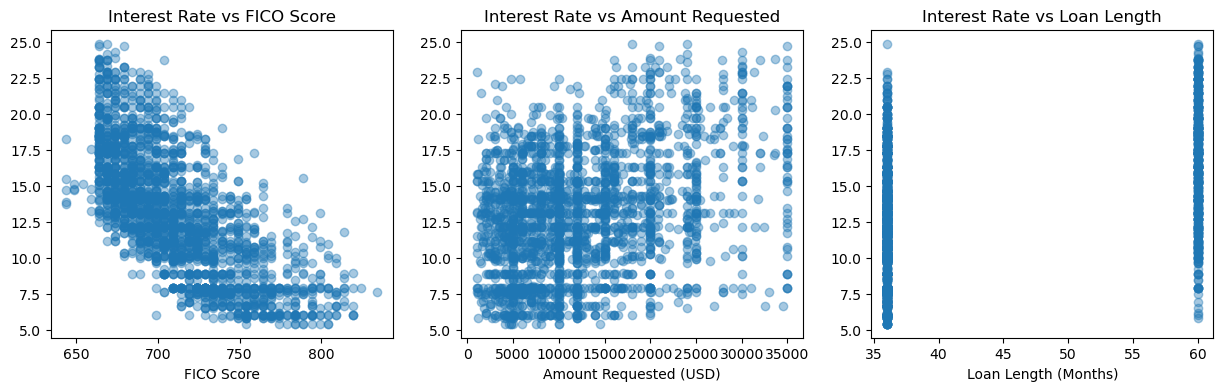

In [99]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.scatter(loan_df['fico_score'], 
            loan_df['interest_rate'],
            alpha=0.4,
            )
plt.title('Interest Rate vs FICO Score')
plt.xlabel('FICO Score')

plt.subplot(1,3,2)
plt.scatter(loan_df['amount_requested'], 
            loan_df['interest_rate'],
            alpha=0.4
            )
plt.title('Interest Rate vs Amount Requested')
plt.xlabel('Amount Requested (USD)')


plt.subplot(1,3,3)
plt.scatter(loan_df['loan_length'], 
            loan_df['interest_rate'],
            alpha=0.4
            )
plt.title('Interest Rate vs Loan Length')
plt.xlabel('Loan Length (Months)')

plt.show()

Text(0.5, 0, 'Amount Requested (USD)')

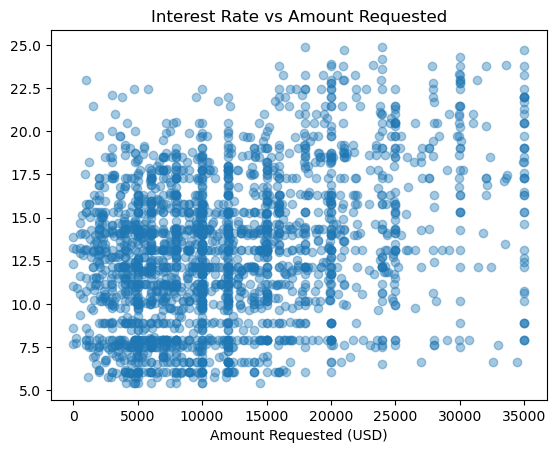

In [100]:
plt.scatter(loan_df['amount_funded_by_investors'], 
            loan_df['interest_rate'],
            alpha=0.4
            )
plt.title('Interest Rate vs Amount Requested')
plt.xlabel('Amount Requested (USD)')

In [101]:
loan_df['difference'] = loan_df['amount_requested'] - loan_df['amount_funded_by_investors']
loan_df['same'] = loan_df['difference'].apply(lambda x: 0 if x != 0 else 1)
loan_df.head()

loan_df['same'].value_counts()

same
1    1818
0     680
Name: count, dtype: int64

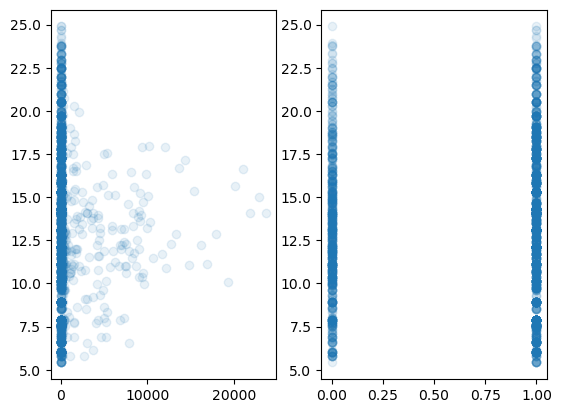

In [102]:
plt.subplot(1,2,1)
plt.scatter(loan_df['difference'],
            loan_df['interest_rate'],
            alpha=0.1
            )


plt.subplot(1,2,2)
plt.scatter(loan_df['same'],
            loan_df['interest_rate'],
            alpha=0.1
            )

In [103]:
loan_df['fico_score'].value_counts()

fico_score
674    171
679    166
684    157
699    153
669    145
694    140
689    137
709    134
704    131
664    125
724    114
714    112
734     94
729     94
719     93
739     65
754     61
749     54
744     53
759     46
764     46
769     36
784     28
779     22
794     20
789     19
774     17
799     13
804     12
809     11
814      8
819      6
644      5
659      4
649      3
834      1
824      1
654      1
Name: count, dtype: int64

In [104]:
X = loan_df[["fico_score", "amount_requested", "loan_length", 'amount_funded_by_investors']]
y = loan_df["interest_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("Train score: ", lin_model.score(X_train, y_train))
print("Test score: ", lin_model.score(X_test, y_test))


Train score:  0.7445761417904011
Test score:  0.7528441934839087


In [105]:
def select_best_depth(X, y, max_depth):

    # Split data
    X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
    )

    X_train, X_vals, y_train, y_vals = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=1
        )

    best_depth = None
    best_score = -float("inf")

    # Train Regressor at each depth
    for depth in range(1, max_depth + 1):
        model = DecisionTreeRegressor(max_depth=depth, random_state=1)
        model.fit(X_train, y_train)

        val_score = model.score(X_vals, y_vals)

        if val_score > best_score:
            best_score = val_score
            best_depth = depth

    # Train the data
    model = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
    model.fit(X_temp, y_temp)
    final_score = model.score(X_test, y_test)

    return final_score, best_depth

In [111]:
print(select_best_depth(X, y, 15))

(0.7640991308694584, 6)


In [107]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=1)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Residual Plots

In [108]:
loan_df['predicted'] = dt_model.predict(X)
loan_df['residual'] = loan_df['interest_rate'] - loan_df['predicted']
loan_df

,interest_rate,fico_range,amount_requested,amount_funded_by_investors,loan_length,fico_score,difference,same,predicted,residual
0,8.90,735-739,20000.0,20000.00,36.0,739,0.00,1,9.397692,-0.497692
1,12.12,715-719,19200.0,19200.00,36.0,719,0.00,1,12.438462,-0.318462
2,21.98,690-694,35000.0,35000.00,60.0,694,0.00,1,21.224583,0.755417
3,9.99,695-699,10000.0,9975.00,36.0,699,25.00,0,12.703664,-2.713664
4,11.71,695-699,12000.0,12000.00,36.0,699,0.00,1,12.703664,-0.993664
...,...,...,...,...,...,...,...,...,...,...
2493,16.77,705-709,30000.0,29950.00,60.0,709,50.00,0,18.536000,-1.766000
2494,14.09,740-744,16000.0,16000.00,60.0,744,0.00,1,12.840606,1.249394
2495,13.99,680-684,10000.0,10000.00,36.0,684,0.00,1,14.064324,-0.074324
2496,12.42,675-679,6000.0,6000.00,36.0,679,0.00,1,14.329655,-1.909655


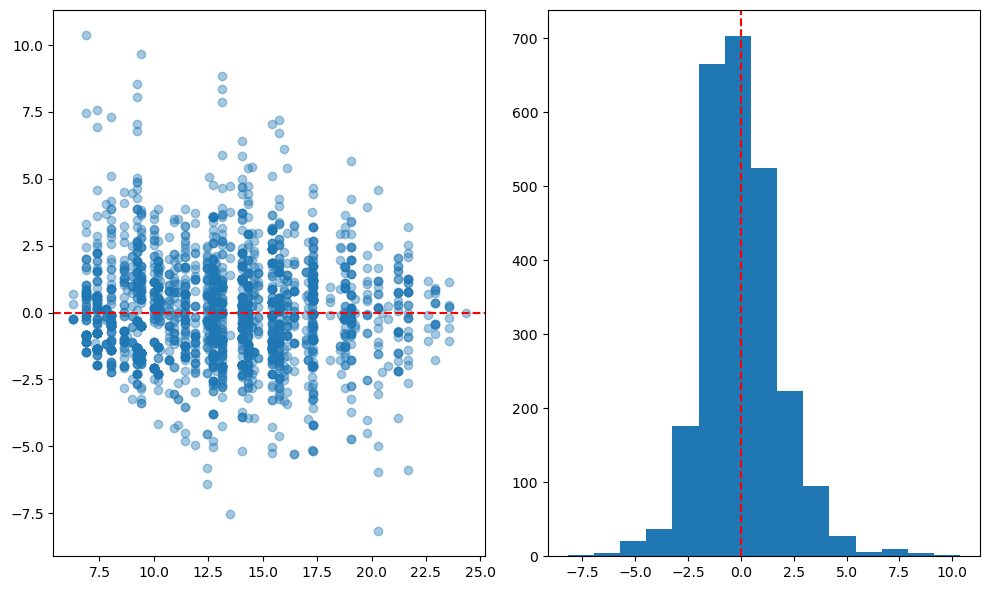

In [109]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(x=loan_df['predicted'],
            y= loan_df['residual'],
            alpha=0.4)
plt.axhline(y=0, color='red', linestyle = '--')

plt.subplot(1,2,2)
plt.hist(loan_df['residual'], bins=15)
plt.axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [110]:
importances = dt_model.feature_importances_

for feat, importance in zip(X_train.columns, importances):
    print(f'Feature:  {feat} || Importance: {importance}')

Feature:  fico_score || Importance: 0.6755502295310383
Feature:  amount_requested || Importance: 0.03904765486570016
Feature:  loan_length || Importance: 0.21504034529057423
Feature:  amount_funded_by_investors || Importance: 0.07036177031268724
